<a href="https://colab.research.google.com/github/Sanika-tech123/Advanced-Machine-Learning-Practicals/blob/main/Apriori_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Install + Import**

In [8]:
!pip install mlxtend pandas

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings("ignore")

In [9]:
import warnings
warnings.filterwarnings("ignore")

**Step 2: Upload Dataset**

In [10]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

Saving Groceries_dataset.csv to Groceries_dataset.csv


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


**Step 3: Convert into Transactions**

In [11]:
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list)

transactions = transactions.tolist()

print(transactions[:5])

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


**Step 4: Encode Data**

In [12]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Step 5: Apply Apriori**

In [21]:
frequent_itemsets = apriori(df_encoded, min_support=0.003, use_colnames=True)

frequent_itemsets.head()

,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.008087,(baking powder)
3,0.033950,(beef)
4,0.021787,(berries)


**Step 6: Generate Rules**

In [22]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(whole milk),0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
1,(bottled beer),(other vegetables),0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
2,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
3,(bottled water),(whole milk),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561
4,(brown bread),(whole milk),0.037626,0.157923,0.004478,0.119005,0.753566,1.0,-0.001464,0.955825,-0.253625,0.023435,-0.046216,0.073680


**Step 7: Sort Best Rules**

In [15]:
rules = rules.sort_values(['lift', 'confidence'], ascending=False)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [23]:
print("Number of rules:", len(rules))
rules.head()

Number of rules: 39


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(whole milk),0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
1,(bottled beer),(other vegetables),0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
2,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
3,(bottled water),(whole milk),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561
4,(brown bread),(whole milk),0.037626,0.157923,0.004478,0.119005,0.753566,1.0,-0.001464,0.955825,-0.253625,0.023435,-0.046216,0.073680


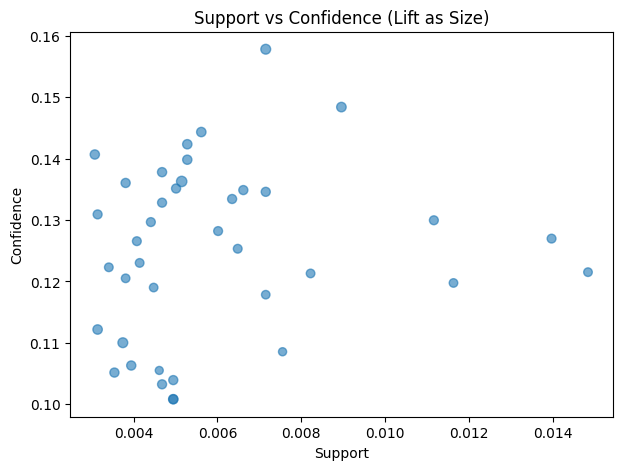

In [24]:
plt.figure(figsize=(7,5))

plt.scatter(
    rules['support'],
    rules['confidence'],
    s=rules['lift']*50,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence (Lift as Size)")

plt.show()